# LOB Domain-Shift Exploration: LOBSTER AAPL vs FI-2010 with Synthetic LOBS5

This notebook is a cleaned implementation for domain-shift analysis in limit order book data.

Scope:
- Cross-market shift: LOBSTER AAPL vs FI-2010
- Synthetic-to-real shift: LOBS5 vs LOBSTER AAPL
- Synthetic-to-benchmark shift: LOBS5 vs FI-2010
- Quantification with KS, Jensen-Shannon divergence, Wasserstein distance, and moment-gap diagnostics
- Slide-ready plots and exported artifacts

## 1. Setup Dependencies and Plot Configuration

In [61]:
%pip install -q datasets huggingface_hub matplotlib seaborn scipy numpy pandas

import os
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy import stats
from scipy.special import rel_entr
from scipy.stats import ks_2samp, wasserstein_distance
from huggingface_hub import hf_hub_download, list_repo_files

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})
sns.set_style('whitegrid')
print('Setup complete.')

Setup complete.


## 2. Define Paths, Dataset Identifiers, and Reproducibility Settings
Create constants for repo IDs, ticker/date file paths, output filenames, random seeds, and optional sample-size limits for quick reruns.

In [62]:
SEED = 42
rng = np.random.default_rng(SEED)

# LOBSTER (HF)
LOBSTER_REPO_ID = 'totalorganfailure/lobster-data'
LOBSTER_FILES = {
    'AAPL': {
        'orderbook': 'LOBSTER_SampleFile_AAPL_2012-06-21_10/AAPL_2012-06-21_34200000_57600000_orderbook_10.csv',
        'message': 'LOBSTER_SampleFile_AAPL_2012-06-21_10/AAPL_2012-06-21_34200000_57600000_message_10.csv',
    }
}

# FI-2010
FI_URL = 'https://raw.githubusercontent.com/zcakhaa/DeepLOB-Deep-Convolutional-Neural-Networks-for-Limit-Order-Books/master/data/data.zip'
FI_DIR = 'fi2010_data'
FI_CANDIDATE_DIRS = [
    'data (1)',
    'data',
    FI_DIR,
]

# LOBS5 synthetic (LOB-Bench)
LOBS5_REPO_ID = 'peernagy/lob_bench'
LOBS5_TICKER = 'GOOG'
LOBS5_RUN_DIR = 'data_gen_lobs5'
LOBS5_MAX_FILES = 150

# Sampling and outputs
N_MAX_METRIC = 80_000
OUTPUTS = {
    'cross_market_plot': 'cross_market_domain_shift.png',
    'synthetic_shift_plot': 'synthetic_vs_real_domain_shift.png',
    'summary_csv': 'dataset_summary_statistics.csv',
    'metrics_csv': 'domain_shift_metrics.csv',
}

print('Configuration set.')

Configuration set.


## 3. Download LOBSTER Files from Hugging Face
Use hf_hub_download to fetch order book and message CSV files for AAPL and store local paths.

In [63]:
lobster_data = {}
for ticker, paths in LOBSTER_FILES.items():
    lobster_data[ticker] = {}
    for ftype, fpath in paths.items():
        local_path = hf_hub_download(
            repo_id=LOBSTER_REPO_ID,
            filename=fpath,
            repo_type='dataset'
        )
        lobster_data[ticker][ftype] = local_path
        print(f'Downloaded {ticker} {ftype}: {local_path}')

Downloaded AAPL orderbook: /root/.cache/huggingface/hub/datasets--totalorganfailure--lobster-data/snapshots/fb51a829d2b5a78c79468db533ba28c5f1d161d0/LOBSTER_SampleFile_AAPL_2012-06-21_10/AAPL_2012-06-21_34200000_57600000_orderbook_10.csv
Downloaded AAPL message: /root/.cache/huggingface/hub/datasets--totalorganfailure--lobster-data/snapshots/fb51a829d2b5a78c79468db533ba28c5f1d161d0/LOBSTER_SampleFile_AAPL_2012-06-21_10/AAPL_2012-06-21_34200000_57600000_message_10.csv


## 4. Implement LOBSTER Loaders (Order Book + Messages)
Write reusable functions to load headerless CSVs, assign canonical column names, normalize price units, and return typed DataFrames.

In [64]:
def load_lobster_orderbook(filepath, n_levels=10):
    cols = []
    for i in range(1, n_levels + 1):
        cols += [f'ask_price_{i}', f'ask_vol_{i}', f'bid_price_{i}', f'bid_vol_{i}']

    df = pd.read_csv(filepath, header=None, names=cols)
    price_cols = [c for c in df.columns if 'price' in c]
    df[price_cols] = df[price_cols] / 10000.0
    return df


def load_lobster_message(filepath):
    cols = ['time', 'event_type', 'order_id', 'size', 'price', 'direction']
    df = pd.read_csv(filepath, header=None, names=cols)
    df['price'] = df['price'] / 10000.0
    return df

## 5. Compute LOBSTER Features and Horizon Labels
Derive best bid/ask, mid-price, spread, returns, imbalance, depth aggregates, inter-arrival time, and multi-horizon labels using forward shifts.

In [65]:
def compute_lob_features(ob_df, msg_df):
    features = pd.DataFrame()
    features['best_ask'] = ob_df['ask_price_1']
    features['best_bid'] = ob_df['bid_price_1']
    features['mid_price'] = (features['best_ask'] + features['best_bid']) / 2.0
    features['spread'] = features['best_ask'] - features['best_bid']
    features['mid_return'] = features['mid_price'].pct_change()

    features['bid_vol_1'] = ob_df['bid_vol_1']
    features['ask_vol_1'] = ob_df['ask_vol_1']
    denom = (features['bid_vol_1'] + features['ask_vol_1']).replace(0, np.nan)
    features['order_imbalance'] = (features['bid_vol_1'] - features['ask_vol_1']) / denom

    bid_vol_cols = [c for c in ob_df.columns if c.startswith('bid_vol')]
    ask_vol_cols = [c for c in ob_df.columns if c.startswith('ask_vol')]
    features['total_bid_depth'] = ob_df[bid_vol_cols].sum(axis=1)
    features['total_ask_depth'] = ob_df[ask_vol_cols].sum(axis=1)

    if msg_df is not None and len(msg_df) == len(ob_df):
        features['time'] = msg_df['time']
        features['inter_arrival'] = features['time'].diff()

    def compute_labels(mid_price, h, eps=1e-5):
        future_price = mid_price.shift(-h)
        diff = future_price - mid_price
        return np.where(diff > eps, 3, np.where(diff < -eps, 1, 2))

    features['label_h10'] = compute_labels(features['mid_price'], 10)
    features['label_h20'] = compute_labels(features['mid_price'], 20)
    features['label_h50'] = compute_labels(features['mid_price'], 50)

    features = features.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    return features

ob = {}
msg = {}
feat = {}
ob['AAPL'] = load_lobster_orderbook(lobster_data['AAPL']['orderbook'])
msg['AAPL'] = load_lobster_message(lobster_data['AAPL']['message'])
feat['AAPL'] = compute_lob_features(ob['AAPL'], msg['AAPL'])
print(f"AAPL: OB={ob['AAPL'].shape}, MSG={msg['AAPL'].shape}, FEAT={feat['AAPL'].shape}")

AAPL: OB=(400391, 40), MSG=(400391, 6), FEAT=(400390, 15)


## 6. Download and Discover FI-2010 Files
Download/unzip FI-2010 source files, recursively enumerate .txt/.npy assets, and print discovered structure for robust loading.

In [66]:
import subprocess

def discover_fi_files(root_dir):
    npy_files = glob.glob(f'{root_dir}/**/*.npy', recursive=True)
    txt_files = glob.glob(f'{root_dir}/**/*.txt', recursive=True)
    all_data_files = glob.glob(f'{root_dir}/**/*', recursive=True)
    return npy_files, txt_files, all_data_files

npy_files, txt_files, all_data_files = [], [], []
fi_active_dir = None
for cand in FI_CANDIDATE_DIRS:
    if Path(cand).exists():
        npy_files, txt_files, all_data_files = discover_fi_files(cand)
        if len(npy_files) > 0 or len(txt_files) > 0:
            fi_active_dir = cand
            break

if fi_active_dir is None:
    print('No local FI-2010 files found in candidates. Downloading fallback archive...')
    subprocess.run(['wget', '-q', '-O', 'data.zip', FI_URL], check=True)
    subprocess.run(['unzip', '-qo', 'data.zip', '-d', FI_DIR], check=True)
    fi_active_dir = FI_DIR
    npy_files, txt_files, all_data_files = discover_fi_files(fi_active_dir)

print(f'Using FI-2010 directory: {fi_active_dir}')
print(f'Found {len(npy_files)} .npy files')
print(f'Found {len(txt_files)} .txt files')
print(f'Total files: {len(all_data_files)}')
for f in all_data_files[:20]:
    print(' ', f)

Using FI-2010 directory: fi2010_data
Found 0 .npy files
Found 4 .txt files
Total files: 4
  fi2010_data/Test_Dst_NoAuction_DecPre_CF_9.txt
  fi2010_data/Train_Dst_NoAuction_DecPre_CF_7.txt
  fi2010_data/Test_Dst_NoAuction_DecPre_CF_7.txt
  fi2010_data/Test_Dst_NoAuction_DecPre_CF_8.txt


## 7. Implement FI-2010 Loader and Matrix Parsing
Load DeepLOB-format training files (or fallback .npy), concatenate along time axis, and retain raw matrix metadata for diagnostics.

In [67]:
def load_fi2010(data_dir=None):
    # Resolve directory if not explicitly provided.
    if data_dir is None:
        candidate_dirs = [fi_active_dir] if 'fi_active_dir' in globals() and fi_active_dir else FI_CANDIDATE_DIRS
        candidate_dirs = [d for d in candidate_dirs if d is not None]
        data_dir = None
        for d in candidate_dirs:
            if Path(d).exists():
                has_txt = len(glob.glob(f'{d}/**/*.txt', recursive=True)) > 0
                has_npy = len(glob.glob(f'{d}/**/*.npy', recursive=True)) > 0
                if has_txt or has_npy:
                    data_dir = d
                    break
        if data_dir is None:
            print('No FI-2010 data directory with .txt/.npy found.')
            return None, {}

    patterns = [
        f'{data_dir}/**/Train_Dst_NoAuction_ZScore_CF_*.txt',
        f'{data_dir}/**/NoAuction_Zscore_Training/Train_Dst_NoAuction_ZScore_CF_*.txt',
        f'{data_dir}/**/*Train*.txt',
        f'{data_dir}/**/*.txt',
    ]

    train_files = []
    for pattern in patterns:
        train_files = sorted(glob.glob(pattern, recursive=True))
        if train_files:
            break

    if not train_files:
        npy_files = sorted(glob.glob(f'{data_dir}/**/*.npy', recursive=True))
        if npy_files:
            data = np.load(npy_files[0])
            print(f'Loaded .npy file: {npy_files[0]}, shape: {data.shape}')
            return data, {'source': npy_files[0], 'n_files': 1, 'data_dir': data_dir}
        print('No FI-2010 data files found!')
        return None, {'data_dir': data_dir}

    all_data = []
    for f in train_files:
        d = np.loadtxt(f)
        all_data.append(d)
    data = np.hstack(all_data)
    meta = {
        'source': 'txt',
        'n_files': len(train_files),
        'files': train_files[:5],
        'data_dir': data_dir,
    }
    print(f'Combined FI-2010 data shape: {data.shape}')
    return data, meta

fi2010_raw, fi2010_meta = load_fi2010()
print(fi2010_meta)

Combined FI-2010 data shape: (149, 254750)
{'source': 'txt', 'n_files': 1, 'files': ['fi2010_data/Train_Dst_NoAuction_DecPre_CF_7.txt'], 'data_dir': 'fi2010_data'}


## 8. Convert FI-2010 to Comparable Feature Set
Extract first 40 LOB rows, map level-wise features, compute comparable microstructure features, and attach available FI labels.

In [68]:
def fi2010_to_features(data):
    if data is None:
        return None

    lob = data[:40, :]
    features = pd.DataFrame()
    features['ask_price_1'] = lob[0, :]
    features['ask_vol_1'] = lob[1, :]
    features['bid_price_1'] = lob[2, :]
    features['bid_vol_1'] = lob[3, :]
    features['mid_price'] = (features['ask_price_1'] + features['bid_price_1']) / 2.0
    features['spread'] = features['ask_price_1'] - features['bid_price_1']
    features['mid_return'] = features['mid_price'].diff()
    features['order_imbalance'] = (
        (features['bid_vol_1'] - features['ask_vol_1']) /
        (features['bid_vol_1'] + features['ask_vol_1']).replace(0, np.nan)
    )

    bid_vols = lob[[4 * i + 3 for i in range(10)], :]
    ask_vols = lob[[4 * i + 1 for i in range(10)], :]
    features['total_bid_depth'] = bid_vols.sum(axis=0)
    features['total_ask_depth'] = ask_vols.sum(axis=0)

    if data.shape[0] > 144:
        features['label_h10'] = data[144, :]
        features['label_h50'] = data[147, :]

    features = features.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    return features

fi2010_feat = fi2010_to_features(fi2010_raw)
print(f'FI-2010 features: {None if fi2010_feat is None else fi2010_feat.shape}')

FI-2010 features: (254749, 12)


## 8.1 Load LOBS5 Synthetic Data and Convert to Comparable Features
Load synthetic message files from LOB-Bench, reconstruct L2 snapshots, and compute the same feature schema used for LOBSTER/FI-2010 comparisons.

In [69]:
def load_lobs5_messages_and_reconstruct(repo_id, ticker, run_dir, max_files=150, n_levels=10):
    all_files = list_repo_files(repo_id, repo_type='dataset')
    prefix = f'{ticker}/{run_dir}/'
    msg_files = sorted([f for f in all_files if f.startswith(prefix) and '_message_' in f and f.endswith('.csv')])
    if max_files is not None:
        msg_files = msg_files[:max_files]
    if len(msg_files) == 0:
        raise ValueError(f'No LOBS5 message files found under {prefix}')

    def _best_bid(levels):
        return max(levels.keys()) if levels else np.nan

    def _best_ask(levels):
        return min(levels.keys()) if levels else np.nan

    def _add_level(levels, price, delta):
        if not np.isfinite(price) or delta == 0:
            return
        v = levels.get(price, 0.0) + float(delta)
        if v <= 0:
            levels.pop(price, None)
        else:
            levels[price] = v

    def _snapshot(bid_levels, ask_levels):
        snap = {}
        bid_prices = sorted(bid_levels.keys(), reverse=True)[:n_levels]
        ask_prices = sorted(ask_levels.keys())[:n_levels]
        for i in range(1, n_levels + 1):
            bp = bid_prices[i - 1] if i - 1 < len(bid_prices) else np.nan
            ap = ask_prices[i - 1] if i - 1 < len(ask_prices) else np.nan
            snap[f'ask_price_{i}'] = ap
            snap[f'ask_vol_{i}'] = float(ask_levels.get(ap, 0.0)) if np.isfinite(ap) else 0.0
            snap[f'bid_price_{i}'] = bp
            snap[f'bid_vol_{i}'] = float(bid_levels.get(bp, 0.0)) if np.isfinite(bp) else 0.0
        return snap

    def _load_msg(local_path):
        cols = ['time', 'event_type', 'order_id', 'size', 'price', 'direction']
        m = pd.read_csv(local_path, header=None, names=cols)
        med = m['price'].median()
        if np.isfinite(med) and med > 1e4:
            m['price'] = m['price'] / 10000.0
        for c in cols:
            m[c] = pd.to_numeric(m[c], errors='coerce')
        return m

    segments = []
    for i, hf_path in enumerate(msg_files):
        local_path = hf_hub_download(repo_id=repo_id, filename=hf_path, repo_type='dataset')
        m = _load_msg(local_path)
        orders = {}
        bid_levels = {}
        ask_levels = {}
        snaps = []

        for _, r in m.iterrows():
            if pd.isna(r['event_type']) or pd.isna(r['order_id']) or pd.isna(r['direction']):
                s = _snapshot(bid_levels, ask_levels)
                s['time'] = r['time']
                snaps.append(s)
                continue

            et = int(r['event_type'])
            oid = int(r['order_id'])
            size = float(r['size']) if np.isfinite(r['size']) else np.nan
            price = float(r['price']) if np.isfinite(r['price']) else np.nan
            direction = int(r['direction'])

            if not np.isfinite(size) or not np.isfinite(price) or size <= 0:
                s = _snapshot(bid_levels, ask_levels)
                s['time'] = r['time']
                snaps.append(s)
                continue

            if et == 1:
                remaining = size
                if direction == 1:
                    while remaining > 0 and ask_levels:
                        ba = _best_ask(ask_levels)
                        if not np.isfinite(ba) or price < ba:
                            break
                        av = ask_levels[ba]
                        traded = min(remaining, av)
                        av -= traded
                        remaining -= traded
                        if av <= 0:
                            del ask_levels[ba]
                        else:
                            ask_levels[ba] = av
                    if remaining > 0:
                        orders[oid] = (direction, price, remaining)
                        _add_level(bid_levels, price, remaining)
                else:
                    while remaining > 0 and bid_levels:
                        bb = _best_bid(bid_levels)
                        if not np.isfinite(bb) or price > bb:
                            break
                        bv = bid_levels[bb]
                        traded = min(remaining, bv)
                        bv -= traded
                        remaining -= traded
                        if bv <= 0:
                            del bid_levels[bb]
                        else:
                            bid_levels[bb] = bv
                    if remaining > 0:
                        orders[oid] = (direction, price, remaining)
                        _add_level(ask_levels, price, remaining)

            elif et in (2, 4, 5) and oid in orders:
                d0, p0, s0 = orders[oid]
                delta = min(size, s0)
                if d0 == 1:
                    _add_level(bid_levels, p0, -delta)
                else:
                    _add_level(ask_levels, p0, -delta)
                s1 = s0 - delta
                if s1 <= 0:
                    del orders[oid]
                else:
                    orders[oid] = (d0, p0, s1)

            elif et == 3 and oid in orders:
                d0, p0, s0 = orders[oid]
                if d0 == 1:
                    _add_level(bid_levels, p0, -s0)
                else:
                    _add_level(ask_levels, p0, -s0)
                del orders[oid]

            s = _snapshot(bid_levels, ask_levels)
            s['time'] = r['time']
            snaps.append(s)

        ob_seg = pd.DataFrame(snaps)
        ob_seg['segment_id'] = f'{ticker}_{run_dir}_seg_{i:05d}'
        segments.append(ob_seg)

    ob_all = pd.concat(segments, ignore_index=True)
    return ob_all


def compute_lobs5_features_segmented(ob_df, group_col='segment_id'):
    f = pd.DataFrame(index=ob_df.index)
    f[group_col] = ob_df[group_col].values
    f['best_ask'] = ob_df['ask_price_1']
    f['best_bid'] = ob_df['bid_price_1']
    f['mid_price'] = (f['best_ask'] + f['best_bid']) / 2.0
    f['spread'] = f['best_ask'] - f['best_bid']
    f['mid_return'] = f.groupby(group_col)['mid_price'].pct_change()
    f['bid_vol_1'] = ob_df['bid_vol_1']
    f['ask_vol_1'] = ob_df['ask_vol_1']
    denom = (f['bid_vol_1'] + f['ask_vol_1']).replace(0, np.nan)
    f['order_imbalance'] = (f['bid_vol_1'] - f['ask_vol_1']) / denom
    bid_vol_cols = [c for c in ob_df.columns if c.startswith('bid_vol_')]
    ask_vol_cols = [c for c in ob_df.columns if c.startswith('ask_vol_')]
    f['total_bid_depth'] = ob_df[bid_vol_cols].sum(axis=1)
    f['total_ask_depth'] = ob_df[ask_vol_cols].sum(axis=1)
    f['time'] = ob_df['time']
    f['inter_arrival'] = f.groupby(group_col)['time'].diff()
    f = f.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    return f

lobs5_ob = load_lobs5_messages_and_reconstruct(
    repo_id=LOBS5_REPO_ID,
    ticker=LOBS5_TICKER,
    run_dir=LOBS5_RUN_DIR,
    max_files=LOBS5_MAX_FILES,
    n_levels=10,
)
lobs5_feat = compute_lobs5_features_segmented(lobs5_ob)
print('LOBS5 reconstructed orderbook shape:', lobs5_ob.shape)
print('LOBS5 features shape:', lobs5_feat.shape)

LOBS5 reconstructed orderbook shape: (74150, 42)
LOBS5 features shape: (72616, 13)


## 9. Compute Domain-Shift Metrics (AAPL vs FI-2010 and Synthetic Comparisons)
Calculate KS statistics, Jensen-Shannon divergence from KL components via rel_entr, Wasserstein distance, and moment differences for:
- LOBSTER-AAPL vs FI-2010
- LOBS5 vs LOBSTER-AAPL
- LOBS5 vs FI-2010

Each feature is standardized **per-dataset** using that series' own median and IQR before metrics are computed. This removes scale and location differences — including those induced by FI-2010's z-score normalization — so that KS / JS / Wasserstein reflect distributional *shape* divergence rather than raw numerical incompatibility.

In [70]:
METRIC_FEATURES = ['mid_return', 'spread', 'order_imbalance', 'total_bid_depth', 'total_ask_depth']

def _finite(x):
    x = np.asarray(x, dtype=float)
    return x[np.isfinite(x)]

def _standardize_each(x):
    # Per-dataset IQR normalization: center at this series' own median and
    # scale by its own IQR.  Isolates distributional shape from the scale/
    # location differences caused by FI-2010's z-score normalization.
    # Note: FI-2010 returns are diff() on pre-normalized prices; LOBSTER/LOBS5
    # use pct_change() on raw prices — per-dataset normalization handles the
    # resulting scale gap even though the series are conceptually slightly
    # different transformations.
    med = np.median(x)
    q25, q75 = np.percentile(x, [25, 75])
    iqr = q75 - q25
    if iqr <= 0:
        iqr = np.std(x) if np.std(x) > 0 else 1.0
    return (x - med) / iqr

def _kl_js_from_hist(x, y, bins=80, eps=1e-10):
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    if lo == hi:
        return 0.0, 0.0
    edges = np.linspace(lo, hi, bins + 1)
    p, _ = np.histogram(x, bins=edges)
    q, _ = np.histogram(y, bins=edges)
    p = p.astype(float) + eps
    q = q.astype(float) + eps
    p /= p.sum()
    q /= q.sum()
    m = 0.5 * (p + q)
    kl = float(np.sum(rel_entr(p, q)))
    js = float(0.5 * np.sum(rel_entr(p, m)) + 0.5 * np.sum(rel_entr(q, m)))
    return kl, js

def _moment_gap(x, y):
    return {
        'mean_gap': float(np.mean(x) - np.mean(y)),
        'std_gap': float(np.std(x) - np.std(y)),
        'skew_gap': float(stats.skew(x) - stats.skew(y)),
        'kurt_gap': float(stats.kurtosis(x) - stats.kurtosis(y)),
    }

def compute_shift_table(df_a, df_b, name_a, name_b, n_max=N_MAX_METRIC):
    rows = []
    for feat_name in METRIC_FEATURES:
        if feat_name not in df_a.columns or feat_name not in df_b.columns:
            continue
        xa = _finite(df_a[feat_name].values)
        xb = _finite(df_b[feat_name].values)
        if len(xa) < 200 or len(xb) < 200:
            continue
        xa = _standardize_each(xa)
        xb = _standardize_each(xb)
        n = min(len(xa), len(xb), n_max)
        xa = xa[rng.choice(len(xa), n, replace=False)]
        xb = xb[rng.choice(len(xb), n, replace=False)]

        ks = ks_2samp(xa, xb)
        kl, js = _kl_js_from_hist(xa, xb)
        w1 = float(wasserstein_distance(xa, xb))
        mg = _moment_gap(xa, xb)

        rows.append({
            'A': name_a,
            'B': name_b,
            'feature': feat_name,
            'n': int(n),
            'ks_stat': float(ks.statistic),
            'ks_pvalue': float(ks.pvalue),
            'kl_div': kl,
            'js_div': js,
            'wasserstein_1': w1,
            **mg,
        })
    return pd.DataFrame(rows)

metrics_tables = []
if fi2010_feat is not None:
    metrics_tables.append(compute_shift_table(feat['AAPL'], fi2010_feat, 'LOBSTER-AAPL', 'FI-2010'))
if 'lobs5_feat' in globals() and lobs5_feat is not None:
    metrics_tables.append(compute_shift_table(lobs5_feat, feat['AAPL'], 'LOBS5', 'LOBSTER-AAPL'))
    if fi2010_feat is not None:
        metrics_tables.append(compute_shift_table(lobs5_feat, fi2010_feat, 'LOBS5', 'FI-2010'))

shift_metrics_df = pd.concat(metrics_tables, ignore_index=True) if metrics_tables else pd.DataFrame()
display(shift_metrics_df.round(6))
shift_metrics_df.to_csv(OUTPUTS['metrics_csv'], index=False)
print(f"Saved: {OUTPUTS['metrics_csv']}")

,A,B,feature,n,ks_stat,ks_pvalue,kl_div,js_div,wasserstein_1,mean_gap,std_gap,skew_gap,kurt_gap
0,LOBSTER-AAPL,FI-2010,mid_return,80000,0.077662,0.0,1.186790,0.040042,0.252925,0.002354,0.886586,-45.990468,-7105.723013
1,LOBSTER-AAPL,FI-2010,spread,80000,0.169462,0.0,13.998914,0.201986,0.256823,-0.240133,-0.148718,-0.474845,-1.798189
2,LOBSTER-AAPL,FI-2010,order_imbalance,80000,0.097625,0.0,0.376418,0.083073,0.087841,0.077253,0.015880,-0.057255,0.058801
3,LOBSTER-AAPL,FI-2010,total_bid_depth,80000,0.287062,0.0,2.113704,0.115467,0.429480,0.417927,0.798936,5.110131,63.573602
4,LOBSTER-AAPL,FI-2010,total_ask_depth,80000,0.240625,0.0,1.662648,0.111805,0.349456,0.334115,0.543315,2.750438,25.038407
5,LOBS5,LOBSTER-AAPL,mid_return,72616,0.067148,0.0,0.157944,0.045984,0.166700,0.004027,0.006843,2.043862,112.897409
6,LOBS5,LOBSTER-AAPL,spread,72616,0.483764,0.0,2.016512,0.456343,0.485020,0.340428,0.256889,3.195158,19.483900
7,LOBS5,LOBSTER-AAPL,order_imbalance,72616,0.106340,0.0,1.685384,0.109512,0.084248,-0.046537,0.001539,0.252535,0.078665
8,LOBS5,LOBSTER-AAPL,total_bid_depth,72616,0.122094,0.0,0.161070,0.032904,0.245870,-0.244901,-0.487422,-3.528818,-54.056910
9,LOBS5,LOBSTER-AAPL,total_ask_depth,72616,0.131913,0.0,0.236292,0.046422,0.275504,-0.275442,-0.368654,-1.848861,-19.449035


Saved: domain_shift_metrics.csv


## 10. Build Synthetic Comparison Plots (LOBS5 vs LOBSTER/FI-2010)
Panels focus on **where LOBS5 sits** relative to both real datasets — using visualization types that are distinct from the cross-market figure:
- Spread histogram (all 3): leads with the largest residual gap
- QQ plot — LOBS5 return vs LOBSTER-AAPL: shows return alignment
- QQ plot — LOBS5 OI vs FI-2010: shows the unexpected OI alignment
- Depth profile (all 3): LOBS5 ≈ LOBSTER across all 10 levels (uses real per-level data, not approximated)
- JS-Divergence heatmap (features × dataset pairs): quantitative summary of where LOBS5 aligns with which dataset
- Label distribution (h=50): all three datasets compared

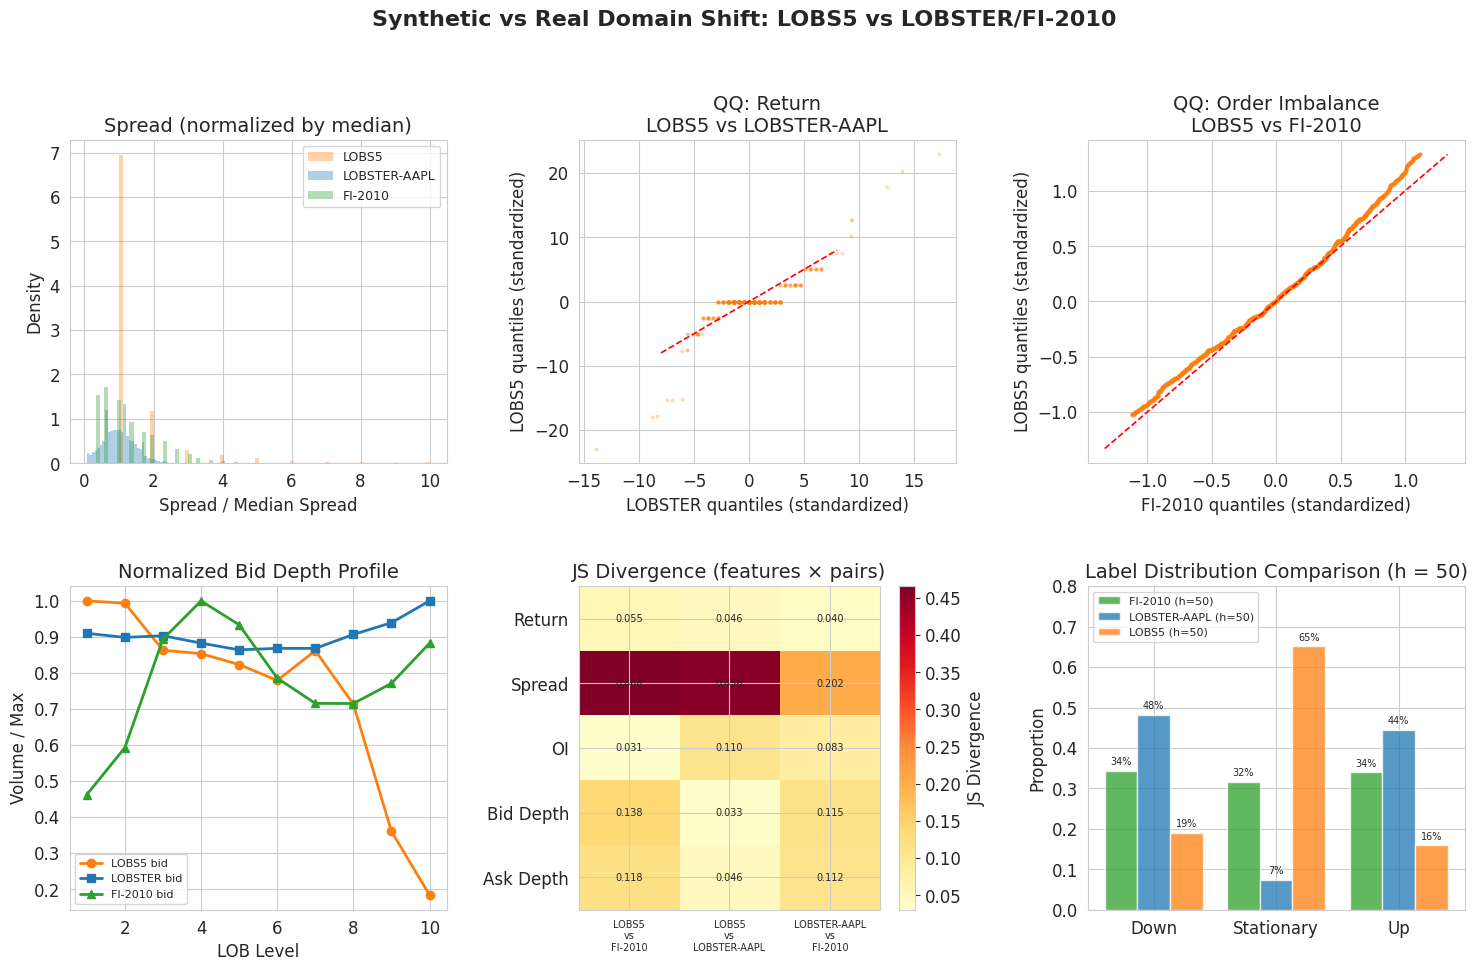

Saved: synthetic_vs_real_domain_shift.png


In [71]:
if 'lobs5_feat' in globals() and lobs5_feat is not None:
    fig = plt.figure(figsize=(18, 10))
    fig.suptitle('Synthetic vs Real Domain Shift: LOBS5 vs LOBSTER/FI-2010', fontsize=16, fontweight='bold', y=1.01)

    gs = gridspec.GridSpec(2, 3, hspace=0.38, wspace=0.35)
    colors = {
        'LOBS5': '#ff7f0e',
        'LOBSTER-AAPL': '#1f77b4',
        'FI-2010': '#2ca02c',
    }

    data_map = {'LOBS5': lobs5_feat, 'LOBSTER-AAPL': feat['AAPL']}
    if fi2010_feat is not None:
        data_map['FI-2010'] = fi2010_feat

    # [0,0] Spread histogram — leads with the largest-gap story (LOBS5 fails to match either real spread)
    ax = fig.add_subplot(gs[0, 0])
    for name, df in data_map.items():
        sp = df['spread'].dropna()
        sp_norm = (sp / sp.median()).clip(upper=10)
        ax.hist(sp_norm, bins=80, alpha=0.35, density=True, label=name, color=colors[name], edgecolor='none')
    ax.set_title('Spread (normalized by median)')
    ax.set_xlabel('Spread / Median Spread')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

    # Per-dataset IQR standardization for QQ plots (same logic as _standardize_each in metrics cell)
    def _std_series(s):
        s = np.asarray(s.dropna(), dtype=float)
        med = np.median(s)
        q25, q75 = np.percentile(s, [25, 75])
        iqr = q75 - q25
        if iqr <= 0:
            iqr = float(np.std(s)) or 1.0
        return (s - med) / iqr

    n_qq = 3000

    # [0,1] QQ: LOBS5 return vs LOBSTER-AAPL — tight diagonal hugging shows return alignment
    ax = fig.add_subplot(gs[0, 1])
    sy_ret = np.sort(rng.choice(_std_series(lobs5_feat['mid_return']), n_qq, replace=False))
    lo_ret = np.sort(rng.choice(_std_series(feat['AAPL']['mid_return']), n_qq, replace=False))
    ax.scatter(lo_ret, sy_ret, alpha=0.2, s=4, color=colors['LOBS5'])
    lim = min(max(np.abs(sy_ret).max(), np.abs(lo_ret).max()), 8)
    ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1.2)
    ax.set_title('QQ: Return\nLOBS5 vs LOBSTER-AAPL')
    ax.set_xlabel('LOBSTER quantiles (standardized)')
    ax.set_ylabel('LOBS5 quantiles (standardized)')

    # [0,2] QQ: LOBS5 OI vs FI-2010 — shows the unexpected OI alignment
    ax = fig.add_subplot(gs[0, 2])
    if fi2010_feat is not None:
        sy_oi = lobs5_feat['order_imbalance'].dropna()
        sy_oi = sy_oi[sy_oi != 0.0]
        fi_oi = fi2010_feat['order_imbalance'].dropna()
        fi_oi = fi_oi[fi_oi != 0.0]
        if len(sy_oi) >= n_qq and len(fi_oi) >= n_qq:
            sy_oi_std = np.sort(rng.choice(_std_series(sy_oi), n_qq, replace=False))
            fi_oi_std = np.sort(rng.choice(_std_series(fi_oi), n_qq, replace=False))
            ax.scatter(fi_oi_std, sy_oi_std, alpha=0.2, s=4, color=colors['LOBS5'])
            lim = min(max(np.abs(sy_oi_std).max(), np.abs(fi_oi_std).max()), 5)
            ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1.2)
    ax.set_title('QQ: Order Imbalance\nLOBS5 vs FI-2010')
    ax.set_xlabel('FI-2010 quantiles (standardized)')
    ax.set_ylabel('LOBS5 quantiles (standardized)')

    # [1,0] Depth Profile — all 3 datasets; LOBS5 uses real per-level data from lobs5_ob (not approximated)
    ax = fig.add_subplot(gs[1, 0])
    levels = np.arange(1, 11)
    lobs5_bid = np.array([lobs5_ob[f'bid_vol_{i}'].mean() for i in range(1, 11)])
    ax.plot(levels, lobs5_bid / lobs5_bid.max(), 'o-', label='LOBS5 bid', color=colors['LOBS5'], linewidth=2)
    lo_bid = np.array([ob['AAPL'][f'bid_vol_{i}'].mean() for i in range(1, 11)])
    ax.plot(levels, lo_bid / lo_bid.max(), 's-', label='LOBSTER bid', color=colors['LOBSTER-AAPL'], linewidth=2)
    if fi2010_feat is not None:
        fi_lob = fi2010_raw[:40, :]
        fi_bid = np.array([np.abs(fi_lob[4 * i + 3, :]).mean() for i in range(10)])
        ax.plot(levels, fi_bid / fi_bid.max(), '^-', label='FI-2010 bid', color=colors['FI-2010'], linewidth=2)
    ax.set_title('Normalized Bid Depth Profile')
    ax.set_xlabel('LOB Level')
    ax.set_ylabel('Volume / Max')
    ax.legend(fontsize=8)

    # [1,1] JS-Divergence heatmap (features x dataset pairs) — shows where LOBS5 aligns with each real dataset
    ax = fig.add_subplot(gs[1, 1])
    if not shift_metrics_df.empty:
        feat_order = ['mid_return', 'spread', 'order_imbalance', 'total_bid_depth', 'total_ask_depth']
        feat_label_map = {
            'mid_return': 'Return', 'spread': 'Spread', 'order_imbalance': 'OI',
            'total_bid_depth': 'Bid Depth', 'total_ask_depth': 'Ask Depth',
        }
        pivot = shift_metrics_df.pivot_table(index='feature', columns=['A', 'B'], values='js_div')
        pivot = pivot.reindex([f for f in feat_order if f in pivot.index])
        pivot.index = [feat_label_map.get(f, f) for f in pivot.index]
        pivot.columns = [f'{a}\nvs\n{b}' for a, b in pivot.columns]
        im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns, fontsize=7)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        plt.colorbar(im, ax=ax, label='JS Divergence')
        for r in range(pivot.shape[0]):
            for c in range(pivot.shape[1]):
                ax.text(c, r, f'{pivot.values[r, c]:.3f}', ha='center', va='center', fontsize=7)
    ax.set_title('JS Divergence (features × pairs)')

    # [1,2] Label Distribution (h=50) — moved here from cross-market figure where LOBS5 was out of place
    ax = fig.add_subplot(gs[1, 2])

    fi_h50 = fi2010_feat['label_h50'] if fi2010_feat is not None and 'label_h50' in fi2010_feat.columns else None
    lo_h50 = feat['AAPL']['label_h50'] if 'label_h50' in feat['AAPL'].columns else None

    if 'label_h50' in lobs5_feat.columns:
        sy_h50 = lobs5_feat['label_h50']
    else:
        eps = 1e-5
        if 'segment_id' in lobs5_feat.columns:
            future_mid = lobs5_feat.groupby('segment_id')['mid_price'].shift(-50)
        else:
            future_mid = lobs5_feat['mid_price'].shift(-50)
        diff = future_mid - lobs5_feat['mid_price']
        sy_h50 = pd.Series(np.where(diff > eps, 3, np.where(diff < -eps, 1, 2))).dropna()

    label_names = ['Down', 'Stationary', 'Up']
    classes = [1, 2, 3]
    datasets = []
    if fi_h50 is not None:
        datasets.append(('FI-2010', fi_h50, colors['FI-2010']))
    if lo_h50 is not None:
        datasets.append(('LOBSTER-AAPL', lo_h50, colors['LOBSTER-AAPL']))
    datasets.append(('LOBS5', sy_h50, colors['LOBS5']))

    if len(datasets) > 0:
        x = np.arange(len(classes))
        w = 0.8 / len(datasets)
        for i, (name, lbls, color) in enumerate(datasets):
            vals = pd.Series(lbls).dropna().astype(int)
            pct = np.array([(vals == v).sum() for v in classes], dtype=float)
            pct = pct / pct.sum() if pct.sum() > 0 else pct
            xpos = x - 0.4 + w / 2 + i * w
            bars = ax.bar(xpos, pct, w, label=f'{name} (h=50)', color=color, alpha=0.75, edgecolor='white')
            for b in bars:
                h = b.get_height()
                ax.text(b.get_x() + b.get_width() / 2, h + 0.01, f'{h:.0%}', ha='center', va='bottom', fontsize=7)
        ax.set_xticks(x)
        ax.set_xticklabels(label_names)
        ax.set_ylim(0, 0.8)
        ax.set_title('Label Distribution Comparison (h = 50)')
        ax.set_ylabel('Proportion')
        ax.legend(fontsize=8)

    plt.savefig(OUTPUTS['synthetic_shift_plot'], dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUTPUTS['synthetic_shift_plot']}")
else:
    print('LOBS5 unavailable. Skipping synthetic comparison plot.')

## 11. Build Cross-Market Plots (FI-2010 vs LOBSTER-AAPL)
FI-2010 and LOBSTER-AAPL only — no LOBS5. Panels show the **distributional shape** of each feature and rank their divergence:
- Return KDE: substantial overlap across markets
- Spread histogram: moderate misalignment (feature added here — was missing despite being in the takeaway)
- Order Imbalance KDE: substantial overlap
- Return Tail CCDF (log scale): tail behavior of the two real markets; unique to this figure
- Depth profile (all 10 levels): most divergent feature
- Feature-level KS statistic bar: quantifies the ranking — depth &gt; spread &gt; OI ≈ return

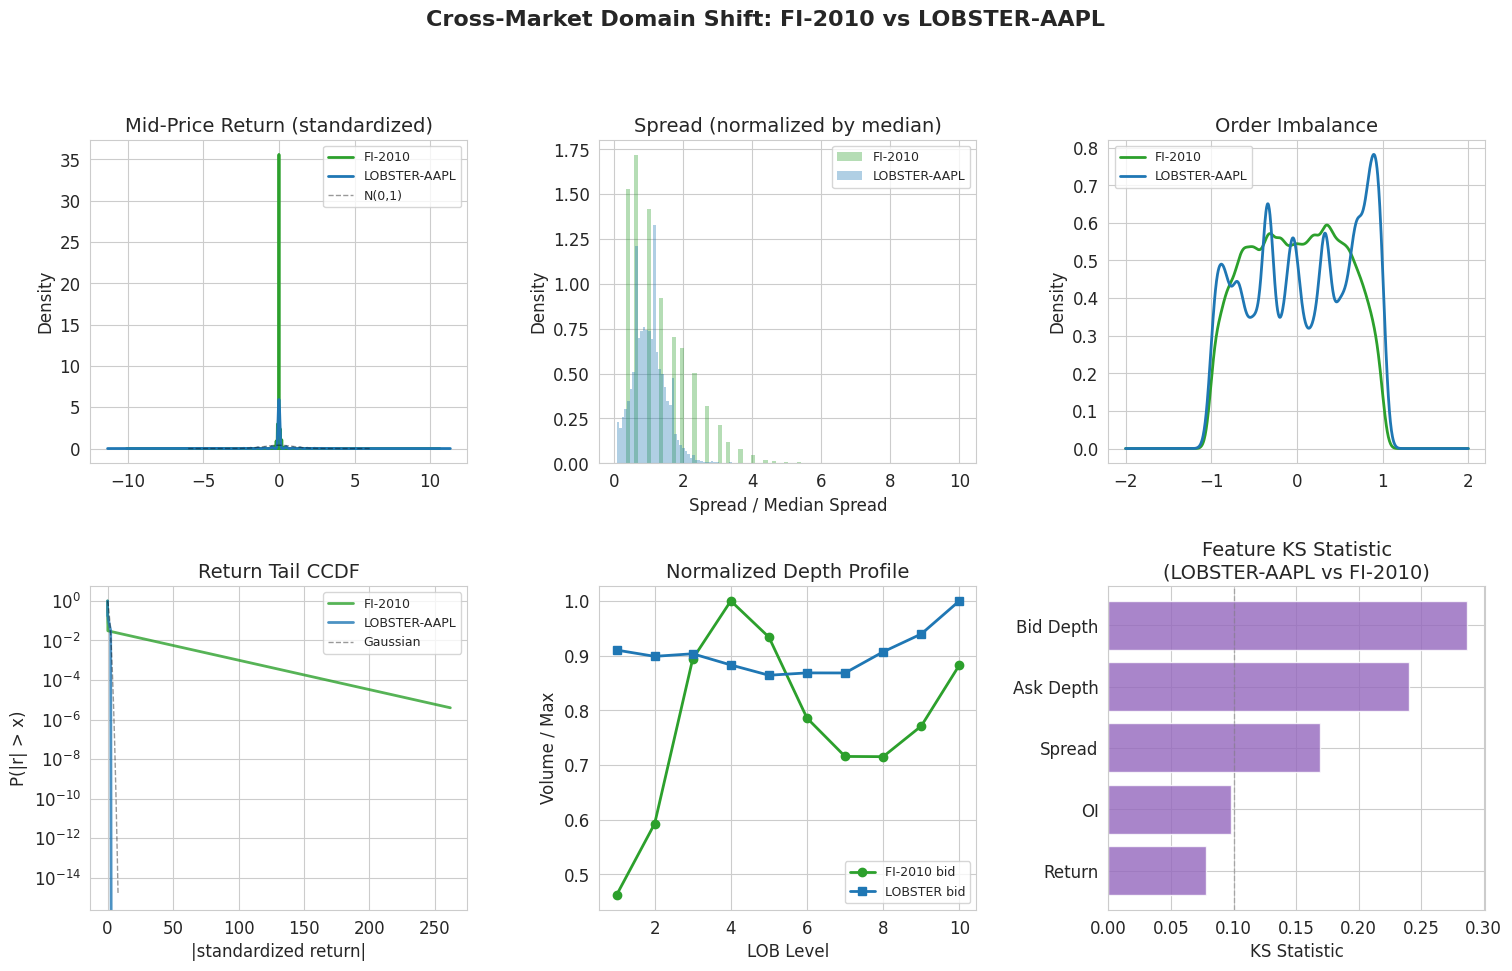

Saved: cross_market_domain_shift.png


In [72]:
if fi2010_feat is not None:
    fig = plt.figure(figsize=(18, 10))
    fig.suptitle('Cross-Market Domain Shift: FI-2010 vs LOBSTER-AAPL', fontsize=16, fontweight='bold', y=1.01)

    gs = gridspec.GridSpec(2, 3, hspace=0.38, wspace=0.35)
    c_fi, c_lo, c_sy = '#2ca02c', '#1f77b4', '#ff7f0e'

    fi_ret_raw = fi2010_feat['mid_return'].dropna()
    fi_ret_z = (fi_ret_raw - fi_ret_raw.mean()) / (fi_ret_raw.std() if fi_ret_raw.std() > 0 else 1.0)
    lo_ret_raw = feat['AAPL']['mid_return'].dropna()
    lo_ret_z = (lo_ret_raw - lo_ret_raw.mean()) / (lo_ret_raw.std() if lo_ret_raw.std() > 0 else 1.0)

    # [0,0] Return KDE
    ax = fig.add_subplot(gs[0, 0])
    fi_clip = fi_ret_z[(fi_ret_z > -6) & (fi_ret_z < 6)]
    lo_clip = lo_ret_z[(lo_ret_z > -6) & (lo_ret_z < 6)]
    fi_clip.plot.kde(ax=ax, label='FI-2010', color=c_fi, linewidth=2)
    lo_clip.plot.kde(ax=ax, label='LOBSTER-AAPL', color=c_lo, linewidth=2)
    x_ref = np.linspace(-6, 6, 300)
    ax.plot(x_ref, stats.norm.pdf(x_ref), 'k--', linewidth=1, alpha=0.4, label='N(0,1)')
    ax.set_title('Mid-Price Return (standardized)')
    ax.legend(fontsize=9)

    # [0,1] Spread histogram — added to cross-market (was previously missing despite being in the takeaway)
    ax = fig.add_subplot(gs[0, 1])
    for label, df, color in [('FI-2010', fi2010_feat, c_fi), ('LOBSTER-AAPL', feat['AAPL'], c_lo)]:
        sp = df['spread'].dropna()
        sp_norm = (sp / sp.median()).clip(upper=10)
        ax.hist(sp_norm, bins=80, alpha=0.35, density=True, label=label, color=color, edgecolor='none')
    ax.set_title('Spread (normalized by median)')
    ax.set_xlabel('Spread / Median Spread')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

    # [0,2] Order Imbalance KDE
    ax = fig.add_subplot(gs[0, 2])
    fi_oi = fi2010_feat['order_imbalance'].dropna()
    lo_oi = feat['AAPL']['order_imbalance'].dropna()
    fi_oi[fi_oi != 0.0].plot.kde(ax=ax, label='FI-2010', color=c_fi, linewidth=2, bw_method=0.1)
    lo_oi[lo_oi != 0.0].plot.kde(ax=ax, label='LOBSTER-AAPL', color=c_lo, linewidth=2, bw_method=0.1)
    ax.set_title('Order Imbalance')
    ax.legend(fontsize=9)

    # [1,0] Return Tail CCDF — unique to this figure; shows tail alignment between the two real markets
    ax = fig.add_subplot(gs[1, 0])
    for label, data_z, color in [('FI-2010', fi_ret_z, c_fi), ('LOBSTER-AAPL', lo_ret_z, c_lo)]:
        abs_r = np.sort(np.abs(data_z.values))
        ccdf = 1.0 - np.arange(1, len(abs_r) + 1) / len(abs_r)
        idx = np.unique(np.logspace(0, np.log10(len(abs_r) - 1), 400).astype(int))
        ax.plot(abs_r[idx], ccdf[idx], '-', label=label, color=color, linewidth=2, alpha=0.8)
    xg = np.linspace(0.01, 8, 200)
    ax.plot(xg, 2 * (1 - stats.norm.cdf(xg)), 'k--', linewidth=1, alpha=0.4, label='Gaussian')
    ax.set_yscale('log')
    ax.set_title('Return Tail CCDF')
    ax.set_xlabel('|standardized return|')
    ax.set_ylabel('P(|r| > x)')
    ax.legend(fontsize=9)

    # [1,1] Depth Profile — all 10 levels; the most divergent cross-market feature
    ax = fig.add_subplot(gs[1, 1])
    levels = np.arange(1, 11)
    lo_bid = np.array([ob['AAPL'][f'bid_vol_{i}'].mean() for i in range(1, 11)])
    lo_bid_n = lo_bid / lo_bid.max()
    fi_lob = fi2010_raw[:40, :]
    fi_bid = np.array([np.abs(fi_lob[4 * i + 3, :]).mean() for i in range(10)])
    fi_bid_n = fi_bid / fi_bid.max()
    ax.plot(levels, fi_bid_n, 'o-', label='FI-2010 bid', color=c_fi, linewidth=2)
    ax.plot(levels, lo_bid_n, 's-', label='LOBSTER bid', color=c_lo, linewidth=2)
    ax.set_title('Normalized Depth Profile')
    ax.set_xlabel('LOB Level')
    ax.set_ylabel('Volume / Max')
    ax.legend(fontsize=9)

    # [1,2] Feature-level KS statistic — proves depth is the most divergent feature
    ax = fig.add_subplot(gs[1, 2])
    sub = shift_metrics_df[
        (shift_metrics_df['A'] == 'LOBSTER-AAPL') & (shift_metrics_df['B'] == 'FI-2010')
    ].copy()
    feat_label_map = {
        'mid_return': 'Return', 'spread': 'Spread', 'order_imbalance': 'OI',
        'total_bid_depth': 'Bid Depth', 'total_ask_depth': 'Ask Depth',
    }
    sub['feat_label'] = sub['feature'].map(feat_label_map)
    sub = sub.sort_values('ks_stat', ascending=True)
    ax.barh(sub['feat_label'], sub['ks_stat'], color='#9467bd', alpha=0.8)
    ax.axvline(0.1, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_title('Feature KS Statistic\n(LOBSTER-AAPL vs FI-2010)')
    ax.set_xlabel('KS Statistic')

    plt.savefig(OUTPUTS['cross_market_plot'], dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUTPUTS['cross_market_plot']}")
else:
    print('FI-2010 unavailable. Skipping cross-market plot.')

## 12. Generate Summary Statistics and Export Artifacts
Assemble dataset-level summary table (spread, return, depth, imbalance metrics), display rounded results, and save CSV plus PNG figures.

In [73]:
summary_rows = []

summary_rows.append({
    'Dataset': 'LOBSTER-AAPL',
    'N events': len(feat['AAPL']),
    'Avg spread ($)': feat['AAPL']['spread'].mean(),
    'Std spread ($)': feat['AAPL']['spread'].std(),
    'Avg |return|': feat['AAPL']['mid_return'].abs().mean(),
    'Return kurtosis': feat['AAPL']['mid_return'].kurtosis(),
    'Avg bid depth': feat['AAPL']['total_bid_depth'].mean(),
    'Avg ask depth': feat['AAPL']['total_ask_depth'].mean(),
    'Imbalance std': feat['AAPL']['order_imbalance'].std(),
})

if fi2010_feat is not None:
    summary_rows.append({
        'Dataset': 'FI-2010',
        'N events': len(fi2010_feat),
        'Avg spread ($)': fi2010_feat['spread'].mean(),
        'Std spread ($)': fi2010_feat['spread'].std(),
        'Avg |return|': fi2010_feat['mid_return'].abs().mean(),
        'Return kurtosis': fi2010_feat['mid_return'].kurtosis(),
        'Avg bid depth': fi2010_feat['total_bid_depth'].mean(),
        'Avg ask depth': fi2010_feat['total_ask_depth'].mean(),
        'Imbalance std': fi2010_feat['order_imbalance'].std(),
    })

if 'lobs5_feat' in globals() and lobs5_feat is not None:
    summary_rows.append({
        'Dataset': 'LOBS5 (synthetic)',
        'N events': len(lobs5_feat),
        'Avg spread ($)': lobs5_feat['spread'].mean(),
        'Std spread ($)': lobs5_feat['spread'].std(),
        'Avg |return|': lobs5_feat['mid_return'].abs().mean(),
        'Return kurtosis': lobs5_feat['mid_return'].kurtosis(),
        'Avg bid depth': lobs5_feat['total_bid_depth'].mean(),
        'Avg ask depth': lobs5_feat['total_ask_depth'].mean(),
        'Imbalance std': lobs5_feat['order_imbalance'].std(),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.round(6))
summary_df.to_csv(OUTPUTS['summary_csv'], index=False)
print(f"Saved: {OUTPUTS['summary_csv']}")

,Dataset,N events,Avg spread ($),Std spread ($),Avg |return|,Return kurtosis,Avg bid depth,Avg ask depth,Imbalance std
0,LOBSTER-AAPL,400390,0.153488,0.074154,0.000005,57.305516,1828.901721,1496.552911,0.569702
1,FI-2010,254749,0.000384,0.000269,0.000021,129649.686228,0.199624,0.194737,0.532187
2,LOBS5 (synthetic),72616,0.014370,0.011593,0.000003,169.110369,2816.879655,3846.599165,0.517507


Saved: dataset_summary_statistics.csv


## 13. Add Lightweight Validation Cells for Saved Outputs

In [74]:
artifacts = [
    OUTPUTS['cross_market_plot'],
    OUTPUTS['synthetic_shift_plot'],
    OUTPUTS['summary_csv'],
    OUTPUTS['metrics_csv'],
]

print('Artifact validation:')
for name in artifacts:
    p = Path(name).resolve()
    exists = p.exists()
    size = p.stat().st_size if exists else 0
    status = 'OK' if exists else 'MISSING'
    print(f'- {name}: {status} | path={p} | size={size} bytes')

Artifact validation:
- cross_market_domain_shift.png: OK | path=/content/cross_market_domain_shift.png | size=266009 bytes
- synthetic_vs_real_domain_shift.png: OK | path=/content/synthetic_vs_real_domain_shift.png | size=306133 bytes
- dataset_summary_statistics.csv: OK | path=/content/dataset_summary_statistics.csv | size=594 bytes
- domain_shift_metrics.csv: OK | path=/content/domain_shift_metrics.csv | size=3085 bytes
